In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Quick look at data
print(X[:5])
print(y[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
rf_model = RandomForestClassifier(random_state=42)

In [17]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [18]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,              # 5-Fold Cross Validation
    scoring='accuracy',
    n_jobs=-1          # Use all cores
)
grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [19]:
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.9583333333333334


In [20]:
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(1, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

In [21]:
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,         # number of parameter settings to sample
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....001BE2DBC5010>, 'min_samples_leaf': <scipy.stats....001BE2DBCCAF0>, 'min_samples_split': <scipy.stats....001BE2DBCC8D0>, 'n_estimators': <scipy.stats....001BE2DB816E0>}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
print("Best Parameters (Randomized):", random_search.best_params_)
print("Best Accuracy (Randomized):", random_search.best_score_)

Best Parameters (Randomized): {'max_depth': 11, 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 166}
Best Accuracy (Randomized): 0.9583333333333334


In [23]:
best_model = grid_search.best_estimator_  # or random_search.best_estimator_

y_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 1.0


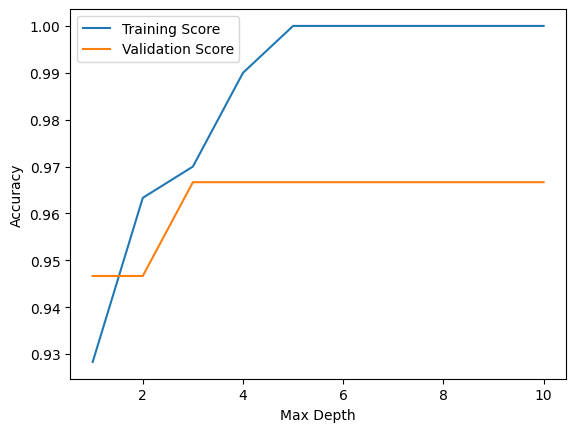

In [ ]:
from sklearn.model_selection import validation_curve

param_range = np.arange(1, 11)
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X, y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, test_mean, label="Validation Score")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [29]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['species'] = data.target_names[data.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
# Encode the target labels (species) to numerical values
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# Split into features and target
X = df.drop(['species'], axis=1)
y = df['species']

# Train‑Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
rf = RandomForestClassifier(random_state=42)

In [32]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters (Grid):", grid_search.best_params_)
print("Best CV Score (Grid):", grid_search.best_score_)

Best Parameters (Grid): {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
Best CV Score (Grid): 0.9583333333333334


In [35]:
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(1, 15),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters (Randomized):", random_search.best_params_)
print("Best CV Score (Randomized):", random_search.best_score_)

Best Parameters (Randomized): {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 124}
Best CV Score (Randomized): 0.9583333333333334


In [36]:
# Pick the best model from GridSearch
best_model = grid_search.best_estimator_

pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



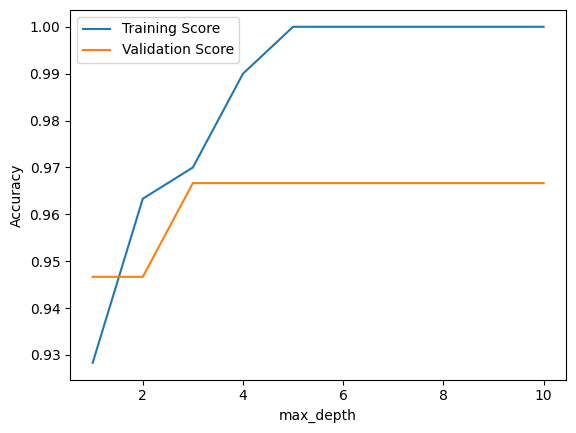

In [37]:
from sklearn.model_selection import validation_curve

param_range = np.arange(1, 11)
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X, y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, val_mean, label="Validation Score")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()